Relative L2 error: 6.44e-07
Predicted u(0) ≈ -1.0000, Target a1 = -1.0
Predicted u(1) ≈ -1.5000, Target a2 = -1.5


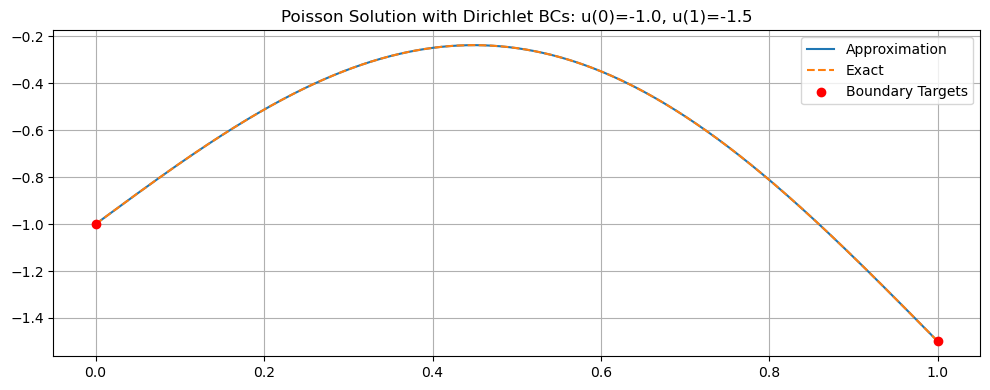

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from numpy.linalg import svd, lstsq, norm

# ----------------------------
# Parameters
# ----------------------------
N = 500
T = 2
M = T * N
c = 0.134
b = c * np.sqrt(N)
tau = 1e-15
beta = 1e4

# User-defined Dirichlet boundary conditions
a1 = -1.0    # u(0) = a1
a2 = -1.5   # u(1) = a2

# ----------------------------
# Domain and Source Function
# ----------------------------
x = np.linspace(0, 1, M)
centers = np.linspace(0, 1, N)
dx = x[1] - x[0]

# Correct exact solution satisfying u(0)=a1, u(1)=a2
u_true = lambda x: np.sin(np.pi * x) + (a2 - a1) * x + a1
f = lambda x: np.pi**2 * np.sin(np.pi * x)
rhs = f(x)

# ----------------------------
# Gaussian RBF and derivatives
# ----------------------------
def rbf(x, c):
    return np.exp(-b**2 * (x[:, None] - c[None, :])**2)

def d2rbf(x, c):
    r = x[:, None] - c[None, :]
    return (4 * b**4 * r**2 - 2 * b**2) * np.exp(-b**2 * r**2)

Phi_raw = rbf(x, centers)
Phi = Phi_raw / np.sqrt(N)
D2Phi = d2rbf(x, centers) / np.sqrt(N)

A1 = D2Phi.T @ D2Phi * dx
r_vec = -D2Phi.T @ rhs * dx

# ----------------------------
# Boundary Penalty Term (Fixed Sign)
# ----------------------------
x_bdry = np.array([0.0, 1.0])
Phi_bdry = rbf(x_bdry, centers) / np.sqrt(N)
g_bdry = u_true(x_bdry)

A3 = np.sqrt(beta / 2) * Phi_bdry
r3 = np.sqrt(beta / 2) * g_bdry  

# Combine
A_total = A1 + A3.T @ A3
b_total = r_vec + A3.T @ r3

# ----------------------------
# Solve using SVD
# ----------------------------
U, S, VT = svd(A_total)
S_inv = np.where(S > tau * np.max(S), 1/S, 0)
w = VT.T @ (S_inv * (U.T @ b_total))

# ----------------------------
# Evaluate and Plot
# ----------------------------
u_pred = Phi @ w
u_exact = u_true(x)
rel_L2_err = np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact)**2

print(f"Relative L2 error: {rel_L2_err:.2e}")
print(f"Predicted u(0) ≈ {u_pred[0]:.4f}, Target a1 = {a1}")
print(f"Predicted u(1) ≈ {u_pred[-1]:.4f}, Target a2 = {a2}")

plt.figure(figsize=(10, 4))
plt.plot(x, u_pred, label='Approximation')
plt.plot(x, u_exact, '--', label='Exact')
plt.scatter(x_bdry, g_bdry, color='red', label='Boundary Targets', zorder=5)
plt.title(f"Poisson Solution with Dirichlet BCs: u(0)={a1}, u(1)={a2}")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


Relative L2 error: 6.44e-07
Predicted u(0) ≈ -1.0000, Target a1 = -1.0
Predicted u(1) ≈ -1.5000, Target a2 = -1.5
Expected u_true(0) = -1.0000, u_true(1) = -1.5000


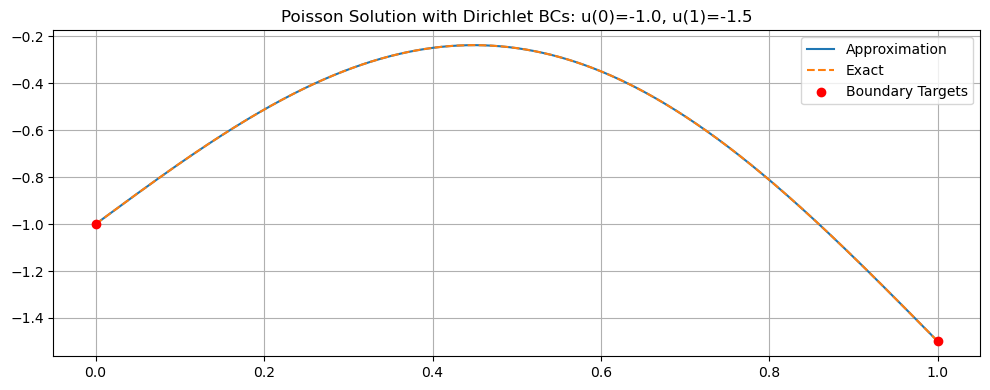

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd
from numba import njit

# ----------------------------
# Parameters
# ----------------------------
N = 500
T = 2
M = T * N
c = 0.134
b = c * np.sqrt(N)
tau = 1e-15
beta = 1e4

# User-defined Dirichlet boundary conditions
a1 = -1.0    # u(0) = a1
a2 = -1.5    # u(1) = a2

# ----------------------------
# Domain and Source Function
# ----------------------------
x = np.linspace(0, 1, M)
centers = np.linspace(0, 1, N)
dx = x[1] - x[0]

# Exact solution and RHS
u_true = lambda x: np.sin(np.pi * x) + (a2 - a1) * x + a1
f = lambda x: np.pi**2 * np.sin(np.pi * x)
rhs = f(x)

# ----------------------------
# Numba-accelerated RBF kernels
# ----------------------------
@njit
def rbf(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = np.exp(-b**2 * r**2)
    return out

@njit
def d2rbf(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = (4 * b**4 * r**2 - 2 * b**2) * np.exp(-b**2 * r**2)
    return out

# ----------------------------
# Build RBF matrices
# ----------------------------
Phi_raw = rbf(x, centers, b)
Phi = Phi_raw / np.sqrt(N)
D2Phi = d2rbf(x, centers, b) / np.sqrt(N)

A1 = D2Phi.T @ D2Phi * dx
r_vec = -D2Phi.T @ rhs * dx

# ----------------------------
# Boundary Penalty Term (Fixed Sign)
# ----------------------------
x_bdry = np.array([0.0, 1.0])
Phi_bdry = rbf(x_bdry, centers, b) / np.sqrt(N)
g_bdry = u_true(x_bdry)

A3 = np.sqrt(beta / 2) * Phi_bdry
r3 = np.sqrt(beta / 2) * g_bdry

# Combine full system
A_total = A1 + A3.T @ A3
b_total = r_vec + A3.T @ r3

# ----------------------------
# Solve using SVD
# ----------------------------
U, S, VT = svd(A_total)
S_inv = np.where(S > tau * np.max(S), 1/S, 0)
w = VT.T @ (S_inv * (U.T @ b_total))

# ----------------------------
# Evaluate and Plot
# ----------------------------
u_pred = Phi @ w
u_exact = u_true(x)
rel_L2_err = np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact)**2

print(f"Relative L2 error: {rel_L2_err:.2e}")
print(f"Predicted u(0) ≈ {u_pred[0]:.4f}, Target a1 = {a1}")
print(f"Predicted u(1) ≈ {u_pred[-1]:.4f}, Target a2 = {a2}")
print(f"Expected u_true(0) = {u_exact[0]:.4f}, u_true(1) = {u_exact[-1]:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(x, u_pred, label='Approximation')
plt.plot(x, u_exact, '--', label='Exact')
plt.scatter(x_bdry, g_bdry, color='red', label='Boundary Targets', zorder=5)
plt.title(f"Poisson Solution with Dirichlet BCs: u(0)={a1}, u(1)={a2}")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


Relative L2 error (truncated SVD): 2.63e-07
Predicted u(0) ≈ -1.0000, Target a1 = -1.0
Predicted u(1) ≈ -1.5000, Target a2 = -1.5
Expected u_true(0) = -1.0000, u_true(1) = -1.5000


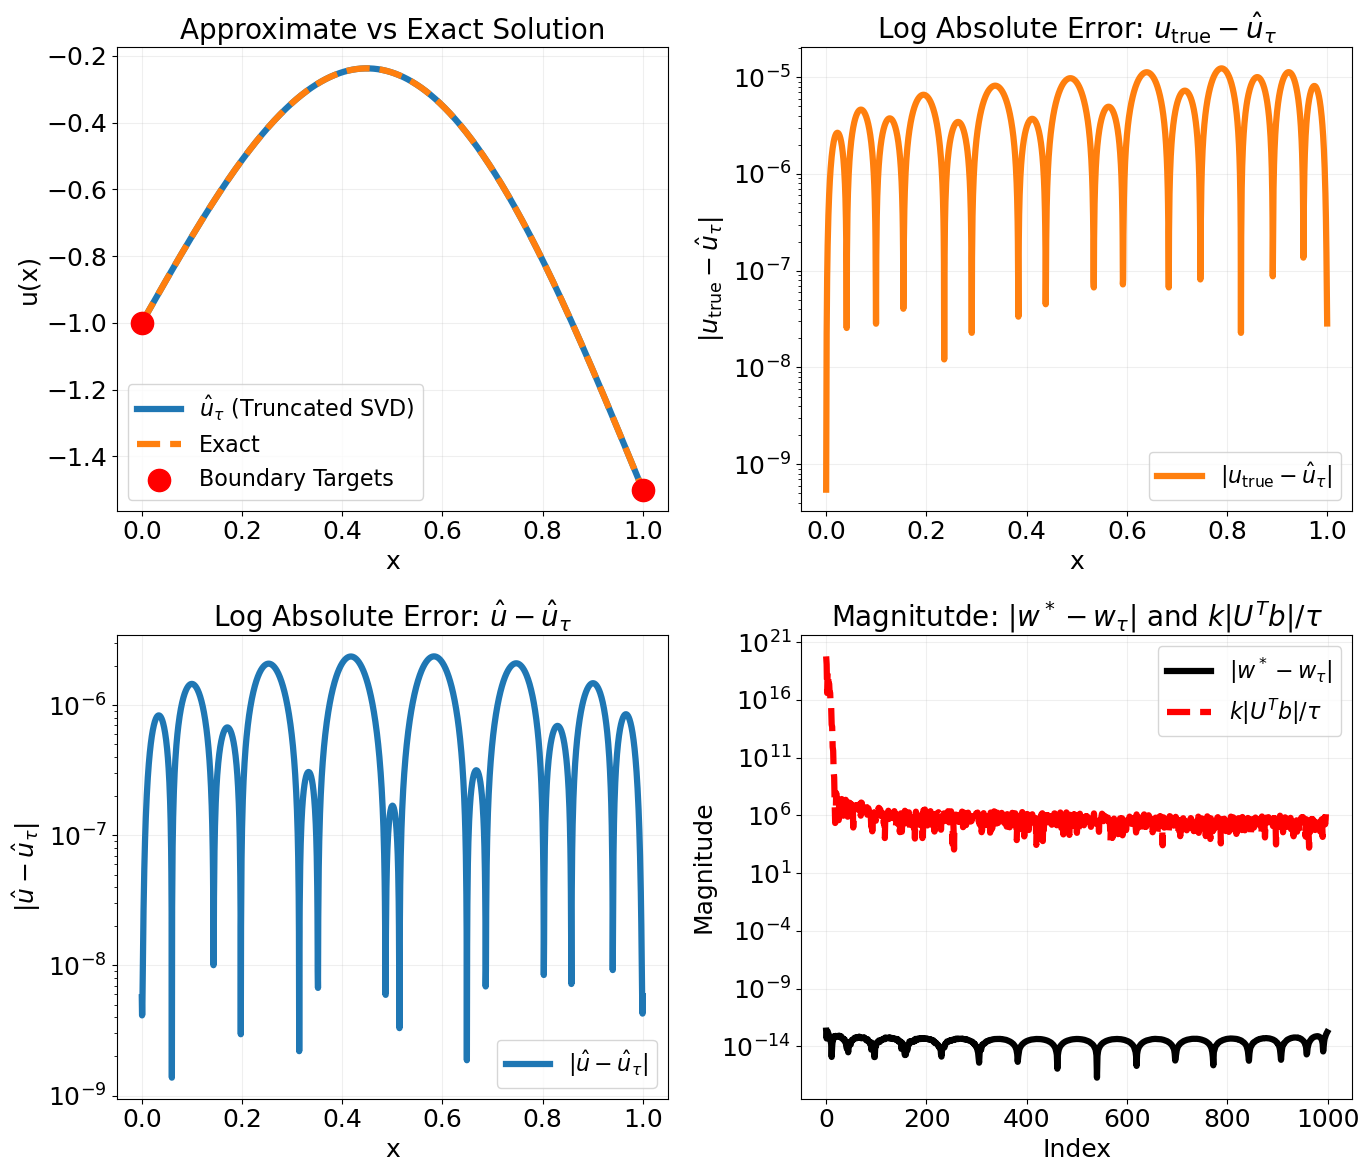

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd
from numba import njit

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from numpy.linalg import svd, lstsq, norm

# ----------------------------
# Parameters
# ----------------------------
N = 1000
T = 2
M = T * N
c = 0.134
b = c * np.sqrt(N)
tau = 1e-15
beta = 1e4

# User-defined Dirichlet boundary conditions
a1 = -1.0    # u(0) = a1
a2 = -1.5    # u(1) = a2

# ----------------------------
# Domain and Source Function
# ----------------------------
x = np.linspace(0, 1, M)
centers = np.linspace(0, 1, N)
dx = x[1] - x[0]

# Exact solution and RHS
u_true = lambda x: np.sin(np.pi * x) + (a2 - a1) * x + a1
f = lambda x: np.pi**2 * np.sin(np.pi * x)
rhs = f(x)

# ----------------------------
# Numba-accelerated RBF kernels
# ----------------------------
@njit
def rbf(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = np.exp(-b**2 * r**2)
    return out

@njit
def d2rbf(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = (4 * b**4 * r**2 - 2 * b**2) * np.exp(-b**2 * r**2)
    return out

# ----------------------------
# Build RBF matrices
# ----------------------------
Phi_raw = rbf(x, centers, b)
Phi = Phi_raw / np.sqrt(N)
D2Phi = d2rbf(x, centers, b) / np.sqrt(N)

A1 = D2Phi.T @ D2Phi * dx
r_vec = -D2Phi.T @ rhs * dx

# ----------------------------
# Boundary Penalty Term (Fixed Sign)
# ----------------------------
x_bdry = np.array([0.0, 1.0])
Phi_bdry = rbf(x_bdry, centers, b) / np.sqrt(N)
g_bdry = u_true(x_bdry)

A3 = np.sqrt(beta / 2) * Phi_bdry
r3 = np.sqrt(beta / 2) * g_bdry

# Combine full system
A_total = A1 + A3.T @ A3
b_total = r_vec + A3.T @ r3

# ----------------------------
# Solve using SVD
# ----------------------------
U, S, VT = svd(A_total)
S_inv = np.where(S > tau * np.max(S), 1/S, 0)
w_tau = VT.T @ (S_inv * (U.T @ b_total))

# 1. Compute the threshold
threshold = tau * S.max()

# 2. Find all i for which S[i] > threshold
retained = np.where(S > threshold)[0]

# 3. The number of retained modes is k
k = retained.size

# 4. If you want the largest retained index (0‐based):
k_max_index = retained.max()  # so modes 0..k_max_index are kept

# ------------------------------------------------------------------ #
# 4.  direct least-squares solution  (w*)
# ------------------------------------------------------------------ #
w_star, *_ =  np.linalg.lstsq(A_total, b_total, rcond = tau)


# Additional diagnostic: |U^T b| / tau
proj_diag = k * np.abs(U.T @ b_total) / tau

# ----------------------------
# Evaluate
# ----------------------------
u_hat_tau = Phi @ w_tau
u_hat = Phi @ w_star
u_exact = u_true(x)

rel_L2_err = np.linalg.norm(u_hat_tau - u_exact) / np.linalg.norm(u_exact)**2
print(f"Relative L2 error (truncated SVD): {rel_L2_err:.2e}")
print(f"Predicted u(0) \u2248 {u_hat_tau[0]:.4f}, Target a1 = {a1}")
print(f"Predicted u(1) \u2248 {u_hat_tau[-1]:.4f}, Target a2 = {a2}")
print(f"Expected u_true(0) = {u_exact[0]:.4f}, u_true(1) = {u_exact[-1]:.4f}")

# ----------------------------
# Plot 2x2 Figures
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# Font sizes
label_fontsize = 18
title_fontsize = 20
tick_fontsize = 18
legend_fontsize = 16
linewidth = 4.5


plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "legend.fontsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "lines.linewidth": 4,
    "lines.markersize": 16,
    "grid.alpha": 0.2,
})


# Top Left: Solution comparison
axs[0, 0].plot(x, u_hat_tau, label=r'$\hat{u}_{\tau}$ (Truncated SVD)', linewidth=linewidth)
axs[0, 0].plot(x, u_exact, '--', label='Exact', linewidth=linewidth)
axs[0, 0].scatter(x_bdry, g_bdry, color='red', label='Boundary Targets', zorder=5)
axs[0, 0].set_title('Approximate vs Exact Solution', fontsize=title_fontsize)
axs[0, 0].set_xlabel('x', fontsize=label_fontsize)
axs[0, 0].set_ylabel('u(x)', fontsize=label_fontsize)
axs[0, 0].tick_params(labelsize=tick_fontsize)
axs[0, 0].legend(fontsize=legend_fontsize)
axs[0, 0].grid(True)

# Top Right: Error between exact and truncated SVD solution
axs[0, 1].plot(x, np.abs(u_exact - u_hat_tau), label=r'$|u_{\mathrm{true}} - \hat{u}_{\tau}|$', linewidth=linewidth, color = 'tab:orange')
axs[0, 1].set_yscale('log')
axs[0, 1].set_title(r'Log Absolute Error: $u_{\mathrm{true}} - \hat{u}_{\tau}$', fontsize=title_fontsize)
axs[0, 1].set_xlabel('x', fontsize=label_fontsize)
axs[0, 1].set_ylabel(r'$|u_{\mathrm{true}} - \hat{u}_{\tau}|$', fontsize=label_fontsize)
axs[0, 1].tick_params(labelsize=tick_fontsize)
axs[0, 1].legend(fontsize=legend_fontsize)
axs[0, 1].grid(True)

# Bottom Left: Difference between full and truncated SVD
axs[1, 0].plot(x, np.abs(u_hat - u_hat_tau), label=r'$|\hat{u} - \hat{u}_{\tau}|$', linewidth=linewidth)
axs[1, 0].set_yscale('log')
axs[1, 0].set_title(r'Log Absolute Error: $\hat{u} - \hat{u}_{\tau}$', fontsize=title_fontsize)
axs[1, 0].set_xlabel('x', fontsize=label_fontsize)
axs[1, 0].set_ylabel(r'$|\hat{u} - \hat{u}_{\tau}|$', fontsize=label_fontsize)
axs[1, 0].tick_params(labelsize=tick_fontsize)
axs[1, 0].legend(fontsize=legend_fontsize)
axs[1, 0].grid(True)

# Bottom Right: Difference in weights
axs[1, 1].plot(np.abs(w_star - w_tau) * tau , label=r'$|w^* - w_{\tau}|$', linewidth=linewidth, color = 'black')
axs[1, 1].plot(proj_diag, '--', label=r'$k|U^T b|/\tau$', linewidth=linewidth, color = 'red')
axs[1, 1].set_yscale('log')
axs[1, 1].set_title(r'Magnitutde: $|w^* - w_{\tau}|$ and $k |U^T b|/\tau$', fontsize=title_fontsize)
axs[1, 1].set_xlabel('Index', fontsize=label_fontsize)
axs[1, 1].set_ylabel('Magnitude', fontsize=label_fontsize)
axs[1, 1].tick_params(labelsize=tick_fontsize)
axs[1, 1].legend(fontsize=legend_fontsize)
axs[1, 1].grid(True)

plt.tight_layout()
plt.savefig('fig1_poisson.png')


# Benchmark for Comparison Methods

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd
from numba import njit
import time
import torch
import torch.nn as nn
import torch.optim as optim
import tracemalloc
import seaborn as sns
import pandas as pd


# ----------------------------
# Numba-accelerated RBF kernels
# ----------------------------
@njit
def rbf(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = np.exp(-b**2 * r**2)
    return out

@njit
def d2rbf(x, c, b):
    out = np.zeros((x.size, c.size))
    for i in range(x.size):
        for j in range(c.size):
            r = x[i] - c[j]
            out[i, j] = (4 * b**4 * r**2 - 2 * b**2) * np.exp(-b**2 * r**2)
    return out


# ----------------------------
# Benchmark Wrapper with Memory Tracking
# ----------------------------
def benchmark_with_memory(solver, N, a1, a2):
    tracemalloc.start()
    result = solver(N, a1, a2)
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return result + (peak / 1024**2,)  # Return in MB

# ----------------------------
# Solver Function
# ----------------------------
def benchmark_solver(N, a1, a2, c=0.134, T=2, beta=1e4, tau=1e-15, jitter = False):
    M = T * N
    b = c * np.sqrt(N)
    x = np.linspace(0, 1, M)
    centers = np.linspace(0, 1, N)
    if jitter:
        noise = np.random.normal(0.01, 1e-1, size=N)
        centers += noise
        centers = np.clip(centers, 0, 1)
    dx = x[1] - x[0]

    u_true = lambda x: np.sin(np.pi * x) + (a2 - a1) * x + a1
    f = lambda x: np.pi**2 * np.sin(np.pi * x)
    rhs = f(x)

    Phi_raw = rbf(x, centers, b)
    Phi = Phi_raw / np.sqrt(N)
    D2Phi = d2rbf(x, centers, b) / np.sqrt(N)

    A1 = D2Phi.T @ D2Phi * dx
    r_vec = -D2Phi.T @ rhs * dx

    x_bdry = np.array([0.0, 1.0])
    Phi_bdry = rbf(x_bdry, centers, b) / np.sqrt(N)
    g_bdry = u_true(x_bdry)

    A3 = np.sqrt(beta / 2) * Phi_bdry
    r3 = np.sqrt(beta / 2) * g_bdry

    A_total = A1 + A3.T @ A3
    b_total = r_vec + A3.T @ r3

    start = time.time()
    U, S, VT = svd(A_total)
    S_inv = np.where(S > tau * np.max(S), 1/S, 0)
    w = VT.T @ (S_inv * (U.T @ b_total))
    elapsed = time.time() - start

    u_pred = Phi @ w
    u_exact = u_true(x)
    rel_L2_err = np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact) ** 2

    return N, rel_L2_err, elapsed

# ----------------------------
# Benchmark Loop
# ----------------------------
# ----------------------------
# Spectral Method Solver (Chebyshev Collocation)
# ----------------------------
def spectral_solver(N, a1, a2):
    x = np.cos(np.pi * np.arange(N + 1) / N)  # Chebyshev points
    x = 0.5 * (x + 1)  # Map from [-1, 1] to [0, 1]
    f = lambda x: np.pi**2 * np.sin(np.pi * x)
    u_true = lambda x: np.sin(np.pi * x) + (a2 - a1) * x + a1

    c = np.ones(N + 1)
    c[0] = c[-1] = 2
    c = c * (-1) ** np.arange(N + 1)
    X = np.tile(x, (N + 1, 1))
    dX = X - X.T + np.eye(N + 1)
    D = np.outer(c, 1 / c) / dX
    D = D - np.diag(np.sum(D, axis=1))

    D2 = D @ D
    D2 = D2[1:-1, 1:-1]
    rhs = f(x)[1:-1]

    start = time.time()
    u_interior = np.linalg.solve(D2, rhs)
    u_pred = np.zeros(N + 1)
    u_pred[0] = a1
    u_pred[-1] = a2
    u_pred[1:-1] = u_interior
    elapsed = time.time() - start

    u_exact = u_true(x)
    err = np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact)
    return N + 1, err, elapsed

# ----------------------------
# Galerkin Solver (2 layers)
# ----------------------------
def galerkin_solver(N, a1, a2):
    x = np.linspace(0, 1, N)
    dx = x[1] - x[0]
    A = np.zeros((N, N))
    b = np.zeros(N)

    f = lambda x: np.pi**2 * np.sin(np.pi * x)
    u_true = lambda x: np.sin(np.pi * x) + (a2 - a1) * x + a1

    for i in range(1, N - 1):
        A[i, i - 1] = 1 / dx**2
        A[i, i] = -2 / dx**2
        A[i, i + 1] = 1 / dx**2
        b[i] = f(x[i])

    A[0, 0] = 1
    b[0] = a1
    A[-1, -1] = 1
    b[-1] = a2

    start = time.time()
    u_pred = np.linalg.solve(A, b)
    elapsed = time.time() - start

    u_exact = u_true(x)
    err = np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact)
    return N, err, elapsed

# ----------------------------
# Neural Network Solver
# ----------------------------
class ShallowNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 1)
        )

    def forward(self, x):
        return self.net(x)

def nn_solver(N, a1, a2, epochs=2000, lr=0.01):
    x = np.linspace(0, 1, N).reshape(-1, 1)
    x_tensor = torch.tensor(x, dtype=torch.float32)
    x_tensor.requires_grad = True

    model = ShallowNN()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    def f(x): return np.pi**2 * np.sin(np.pi * x)
    target = lambda x: np.sin(np.pi * x) + (a2 - a1) * x + a1

    start = time.time()
    for _ in range(epochs):
        optimizer.zero_grad()
        u = model(x_tensor)
        du = torch.autograd.grad(u, x_tensor, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        d2u = torch.autograd.grad(du, x_tensor, grad_outputs=torch.ones_like(du), create_graph=True)[0]
        loss_interior = ((d2u + (np.pi**2) * torch.sin(np.pi * x_tensor))**2).mean()
        loss_bc = (model(torch.tensor([[0.0]])).squeeze() - a1)**2 + (model(torch.tensor([[1.0]])).squeeze() - a2)**2
        loss = loss_interior + loss_bc
        loss.backward()
        optimizer.step()
    elapsed = time.time() - start

    with torch.no_grad():
        u_pred = model(x_tensor).numpy().squeeze()
    u_exact = target(x.squeeze())
    err = np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact)
    return N, err, elapsed

# ----------------------------
# Run All Solvers
# ----------------------------
N_values = [8,16,32,64,128,256,512,1024]
a1, a2 = -1.0, -1.5

results_rbf = [benchmark_solver(N, a1, a2) for N in N_values]
results_gal = [galerkin_solver(N, a1, a2) for N in N_values]
results_nn  = [nn_solver(N, a1, a2) for N in N_values]
results_spec = [spectral_solver(N, a1, a2) for N in N_values]


results_rbf = [benchmark_with_memory(benchmark_solver, N, a1, a2) for N in N_values]
results_gal = [benchmark_with_memory(galerkin_solver, N, a1, a2) for N in N_values]
results_nn  = [benchmark_with_memory(nn_solver, N, a1, a2) for N in N_values]
results_spec = [benchmark_with_memory(spectral_solver, N, a1, a2) for N in N_values]


# ----------------------------
# Jitter RBF Boxplot Experiments
# ----------------------------
max_runs = 100 
Ns_jitter = [50, 100, 500, 1000]
a1, a2 = -1.0, -1.5
jitter_results = {N: [] for N in Ns_jitter}

for N in Ns_jitter:
    for _ in range(max_runs):
        _, err, _, _ = benchmark_with_memory(lambda N, a1, a2: benchmark_solver(N, a1, a2, jitter=True), N, a1, a2)
        jitter_results[N].append(err)


# Optional: Print results
df_rbf = pd.DataFrame(results_rbf, columns=['N', 'RBF Error', 'RBF Time', 'RBF Memory (MB)'])
df_gal = pd.DataFrame(results_gal, columns=['N', 'Galerkin Error', 'Galerkin Time', 'Galerkin Memory (MB)'])
df_nn  = pd.DataFrame(results_nn, columns=['N', 'NN Error', 'NN Time', 'NN Memory (MB)'])
df_spec = pd.DataFrame(results_spec, columns=['N', 'Spectral Error', 'Spectral Time', 'Spectral Memory (MB)'])
df_all = pd.concat([df_rbf.set_index('N'), df_gal.set_index('N'), df_nn.set_index('N'), df_spec.set_index('N')], axis=1)
print(df_all)


         RBF Error  RBF Time  RBF Memory (MB)  Galerkin Error  Galerkin Time  \
N                                                                              
8     5.557930e-02  0.000176         0.009819        1.645104       0.000035   
16    1.759726e-04  0.000120         0.025459        1.819822       0.000021   
32    3.968923e-05  0.000149         0.086739        1.915403       0.000026   
64    5.370598e-06  0.000329         0.326485        1.965303       0.000126   
128   9.788211e-06  0.001302         1.274727        1.990790       0.000132   
256   6.404177e-06  0.008242         5.046242        2.003668       0.000631   
512   7.259626e-07  0.067475        20.089211        2.010142       0.004598   
1024  3.137035e-07  0.394624        80.175148        2.013387       0.025259   
9              NaN       NaN              NaN             NaN            NaN   
17             NaN       NaN              NaN             NaN            NaN   
33             NaN       NaN            

/tmp/ipykernel_343251/2494547159.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_violin, x='N', y='Error', palette="Set2",        # valid seaborn palette
/tmp/ipykernel_343251/2494547159.py:64: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='area'` for the same effect.
  sns.violinplot(data=df_violin, x='N', y='Error', palette="Set2",        # valid seaborn palette


         RBF Error  RBF Time  RBF Memory (MB)  Galerkin Error  Galerkin Time  \
N                                                                              
8     5.557930e-02  0.000176         0.009819        1.645104       0.000035   
16    1.759726e-04  0.000120         0.025459        1.819822       0.000021   
32    3.968923e-05  0.000149         0.086739        1.915403       0.000026   
64    5.370598e-06  0.000329         0.326485        1.965303       0.000126   
128   9.788211e-06  0.001302         1.274727        1.990790       0.000132   
256   6.404177e-06  0.008242         5.046242        2.003668       0.000631   
512   7.259626e-07  0.067475        20.089211        2.010142       0.004598   
1024  3.137035e-07  0.394624        80.175148        2.013387       0.025259   
9              NaN       NaN              NaN             NaN            NaN   
17             NaN       NaN              NaN             NaN            NaN   
33             NaN       NaN            

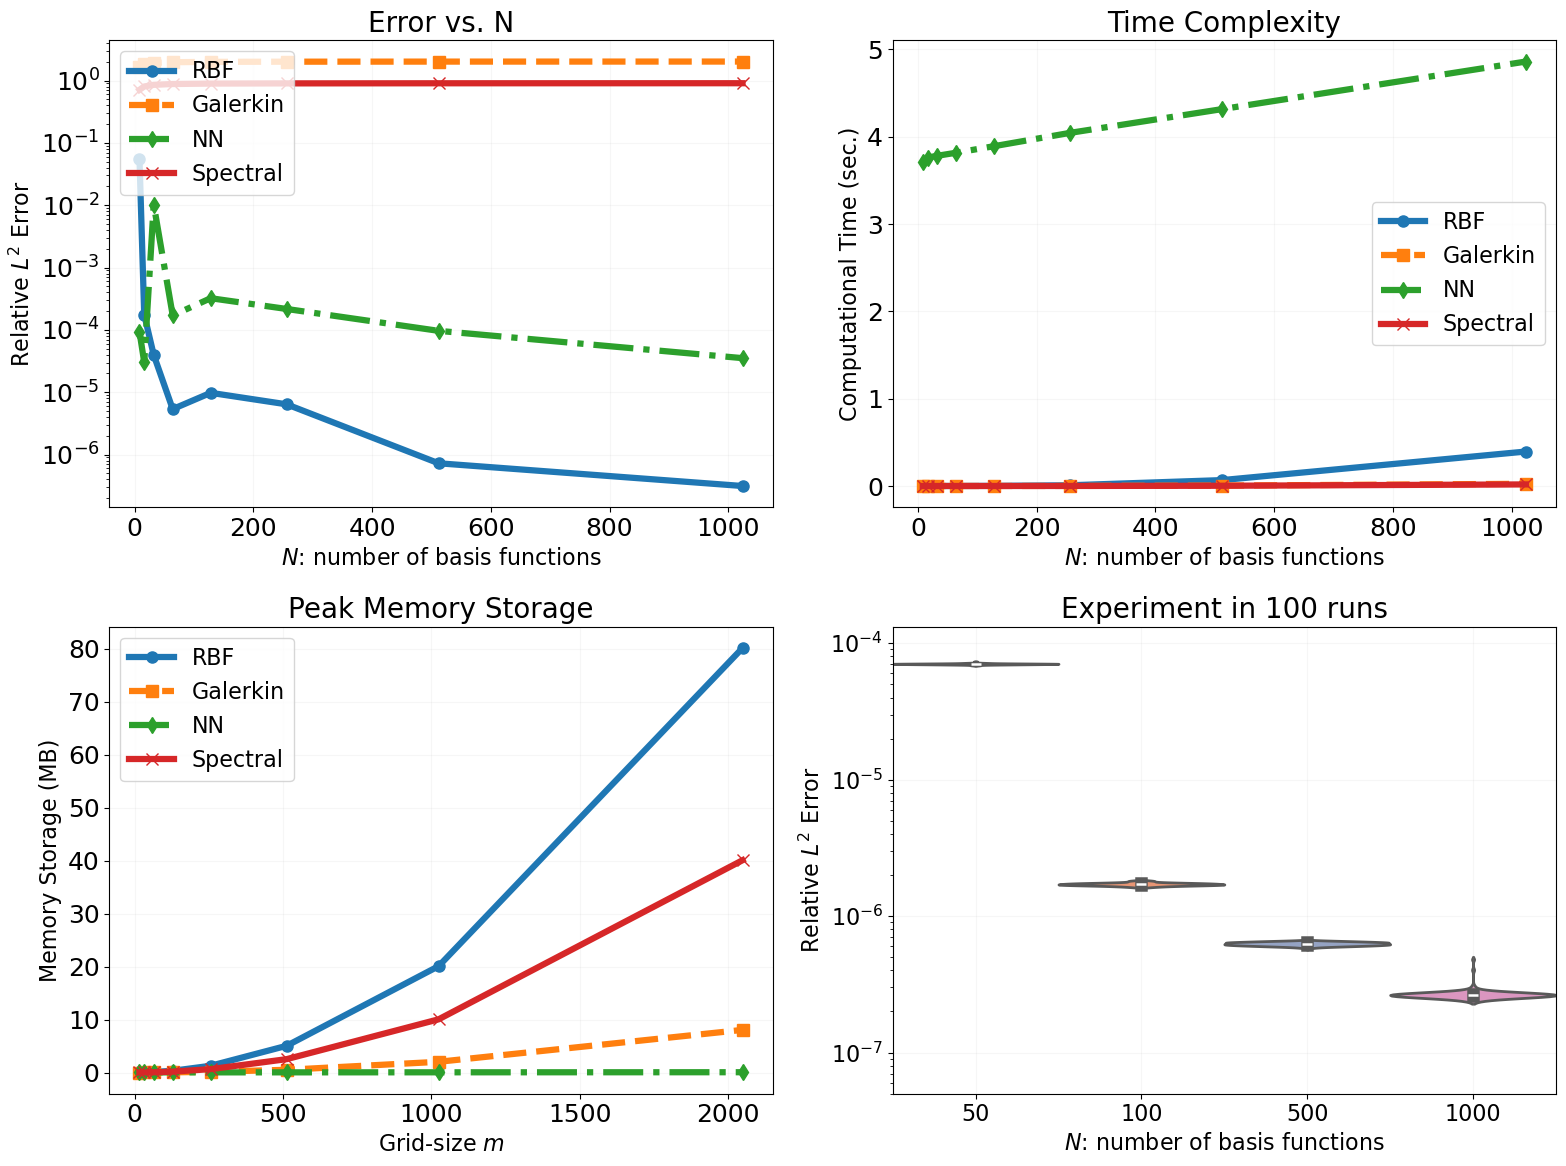

In [60]:
# ----------------------------
# Plot Jitter RBF Violin Plot
# ----------------------------
import matplotlib.ticker as mticker
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 18,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "legend.fontsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "lines.linewidth": 4.5,
    "lines.markersize": 16,
    "grid.alpha": 0.1,
})



T = 2


fig, axs = plt.subplots(2, 2, figsize=(16, 12))

axs[0, 0].plot(N_values, [r[1] for r in results_rbf], 'o-', label='RBF', linewidth=4.5)
axs[0, 0].plot(N_values, [r[1] for r in results_gal], 's--', label='Galerkin', linewidth=4.5)
axs[0, 0].plot(N_values, [r[1] for r in results_nn], 'd-.', label='NN', linewidth=4.5)
axs[0, 0].plot(N_values, [r[1] for r in results_spec], 'x-', label='Spectral', linewidth=4.5)
axs[0, 0].set_yscale('log')
axs[0, 0].set_xlabel('$N$: number of basis functions', fontsize=16)
axs[0, 0].set_ylabel(f'Relative $L^2$ Error', fontsize=16)
axs[0, 0].set_title('Error vs. N', fontsize=20)
axs[0, 0].tick_params(labelsize=18)
axs[0, 0].legend(loc='upper left', fontsize=16)
axs[0, 0].grid(True)

axs[0, 1].plot(N_values, [r[2] for r in results_rbf], 'o-', label='RBF', linewidth=4.5)
axs[0, 1].plot(N_values, [r[2] for r in results_gal], 's--', label='Galerkin', linewidth=4.5)
axs[0, 1].plot(N_values, [r[2] for r in results_nn], 'd-.', label='NN', linewidth=4.5)
axs[0, 1].plot(N_values, [r[2] for r in results_spec], 'x-', label='Spectral', linewidth=4.5)
axs[0, 1].set_xlabel('$N$: number of basis functions', fontsize=16)
axs[0, 1].set_ylabel('Computational Time (sec.)', fontsize=16)
axs[0, 1].set_title('Time Complexity', fontsize=20)
axs[0, 1].tick_params(labelsize=18)
axs[0, 1].legend(loc='best', fontsize=16)
axs[0, 1].grid(True)

axs[1, 0].plot(np.array(N_values) * T, [r[3] for r in results_rbf], 'o-', label='RBF', linewidth=4.5)
axs[1, 0].plot(np.array(N_values) * T, [r[3] for r in results_gal], 's--', label='Galerkin', linewidth=4.5)
axs[1, 0].plot(np.array(N_values) * T, [r[3] for r in results_nn], 'd-.', label='NN', linewidth=4.5)
axs[1, 0].plot(np.array(N_values) * T, [r[3] for r in results_spec], 'x-', label='Spectral', linewidth=4.5)
axs[1, 0].set_xlabel('Grid-size $m$', fontsize=16)
axs[1, 0].set_ylabel('Memory Storage (MB)', fontsize=16)
axs[1, 0].set_title('Peak Memory Storage', fontsize=20)
axs[1, 0].tick_params(labelsize=18)
axs[1, 0].legend(loc='best', fontsize=16)
axs[1, 0].grid(True)

violin_data = []
for N in Ns_jitter:
    for val in jitter_results[N]:
        violin_data.append({'N': N, 'Error': val})
df_violin = pd.DataFrame(violin_data)
sns.violinplot(data=df_violin, x='N', y='Error', palette="Set2",        # valid seaborn palette
    inner="box",         # show median & quartiles
                        # don’t extend beyond data
    scale="area",            # equal width for each violin
    width=1.0,
    linewidth = 2.0,
 
    ax=axs[1, 1])



# — Explicitly set y‐limits to include your full data range (+10% padding) —
ymin = df_violin['Error'].min()
ymax = df_violin['Error'].max()
axs[1, 1].set_ylim(ymin * 0.2, ymax * 1.8)


axs[1, 1].set_yscale('log')
axs[1, 1].set_xlabel("$N$: number of basis functions", fontsize=16)
axs[1, 1].set_ylabel(f"Relative $L^2$ Error", fontsize=16)
axs[1, 1].set_title(f"Experiment in {max_runs:2d} runs", fontsize=20)
axs[1, 1].tick_params(labelsize=16)
axs[1, 1].grid(True)





plt.tight_layout()
plt.savefig('fig2_poisson.png')

# Optional: Print results
df_rbf = pd.DataFrame(results_rbf, columns=['N', 'RBF Error', 'RBF Time', 'RBF Memory (MB)'])
df_gal = pd.DataFrame(results_gal, columns=['N', 'Galerkin Error', 'Galerkin Time', 'Galerkin Memory (MB)'])
df_nn  = pd.DataFrame(results_nn, columns=['N', 'NN Error', 'NN Time', 'NN Memory (MB)'])
df_spec = pd.DataFrame(results_spec, columns=['N', 'Spectral Error', 'Spectral Time', 'Spectral Memory (MB)'])
df_all = pd.concat([df_rbf.set_index('N'), df_gal.set_index('N'), df_nn.set_index('N'), df_spec.set_index('N')], axis=1)
print(df_all)
